<a href="https://colab.research.google.com/github/SGAMA-77/TB_Public-Health-Analysis/blob/main/TB_Public_Health_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: TB Public Health Analysis
This project sought to explore the nature and status of TB based on their indicators. The dataset used is 'tuberculosis_indicators_zaf.csv' from https://data.humdata.org/dataset/who-data-for-zaf to extract key insights, generate informative visualizations, and summarize the findings.

## Load Tuberculosis Indicators Data

In [19]:
import pandas as pd

# Specify the path to the .csv file
csv_file_path = '/content/tuberculosis_indicators_zaf.csv'

# Load the CSV file into a pandas DataFrame
df_tb = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df_tb.head())

# Print the concise summary of the DataFrame
print("\nDataFrame Info:")
df_tb.info()

First 5 rows of the DataFrame:
        GHO (CODE)                                      GHO (DISPLAY)  \
0  #indicator+code                                    #indicator+name   
1             TB_1                    Tuberculosis treatment coverage   
2   MDG_0000000020  Incidence of tuberculosis (per 100 000 populat...   
3     TB_c_new_tsr               Treatment success rate: new TB cases   
4     TB_e_inc_num              Number of incident tuberculosis cases   

                                           GHO (URL) YEAR (DISPLAY)  \
0                                     #indicator+url     #date+year   
1  https://www.who.int/data/gho/data/indicators/i...           2000   
2  https://www.who.int/data/gho/data/indicators/i...           2024   
3  https://www.who.int/data/gho/data/indicators/i...           2020   
4  https://www.who.int/data/gho/data/indicators/i...           2011   

          STARTYEAR         ENDYEAR REGION (CODE) REGION (DISPLAY)  \
0  #date+year+start  #date+year+e

## Analyze and Prepare Data for Visualization

In [20]:
import pandas as pd
import numpy as np

# Re-load the CSV file to ensure a clean DataFrame state
csv_file_path = '/content/tuberculosis_indicators_zaf.csv'
df_tb = pd.read_csv(csv_file_path)

# 1. Remove the first row (metadata)
df_tb = df_tb.iloc[1:].copy()

# Handle column renaming with conflict: remove original 'Value' column first
# The original 'Value' column contains string data like '42 [26-77]', while 'Numeric' has the clean number.
# The instruction is to rename 'Numeric' to 'Value', implying 'Numeric' is the desired source.
if 'Value' in df_tb.columns and 'Numeric' in df_tb.columns:
    df_tb = df_tb.drop(columns=['Value']) # Drop the string-based 'Value' column

# 2. Rename columns for clarity
df_tb = df_tb.rename(columns={
    'GHO (DISPLAY)': 'Indicator',
    'YEAR (DISPLAY)': 'Year',
    'Numeric': 'Value', # Now 'Numeric' can be safely renamed to 'Value'
    'COUNTRY (DISPLAY)': 'Country'
})

# 3. Convert 'Year' to numeric (integer)
df_tb['Year'] = pd.to_numeric(df_tb['Year'], errors='coerce')

# 4. Convert 'Value' to numeric (float), coercing errors to NaN
df_tb['Value'] = pd.to_numeric(df_tb['Value'], errors='coerce')

# 5. Filter out rows where 'Value' is NaN
df_tb = df_tb.dropna(subset=['Value'])

# Convert 'Year' to integer after dropping NaNs, as some values might have been coerced to NaN
df_tb['Year'] = df_tb['Year'].astype(int)

# 6. Inspect the unique values in the 'Indicator' column
unique_indicators = df_tb['Indicator'].unique()
print("\nUnique Indicators after cleaning:")
for indicator in unique_indicators:
    print(indicator)


print("\nFirst 5 rows of the cleaned DataFrame:")
print(df_tb.head())
print("\nDataFrame Info after cleaning:")
df_tb.info()


Unique Indicators after cleaning:
Tuberculosis treatment coverage
Incidence of tuberculosis (per 100 000 population per year)
Treatment success rate: new TB cases
Number of incident tuberculosis cases
Treatment success rate: previously treated TB cases
Treatment success rate: XDR-TB cases
Treatment success rate: HIV-positive TB cases
Treatment success rate for patients treated for MDR-TB (%)
Tuberculosis - new and relapse cases
New cases tested for RR-/MDR-TB (%)
TB patients with known HIV status (%)
Incidence of tuberculosis (per 100 000 population) (HIV-positive cases)
Confirmed cases of RR-/MDR-TB
Number of incident tuberculosis cases,  (HIV-positive cases)
HIV-positive TB patients on ART (antiretroviral therapy) (%)
Tested TB patients HIV-positive (%)
Previously treated cases tested for RR-/MDR-TB (%)
Cases started on MDR-TB treatment
Estimated number of MDR/RR-TB incident cases
Number of incident tuberculosis cases in children aged 0 - 14

First 5 rows of the cleaned DataFrame:
 

In [21]:
import numpy as np

# Select only the relevant columns for analysis
df_tb_cleaned = df_tb[['Indicator', 'Year', 'Value']].copy()

# Define the key indicators identified from the report and unique values inspection
key_indicators = [
    'Incidence of tuberculosis (per 100 000 population per year)',
    'Incidence of tuberculosis (per 100 000 population) (HIV-positive cases)',
    'TB patients with known HIV status (%)',
    'HIV-positive TB patients on ART (antiretroviral therapy) (%)',
    'Treatment success rate: new TB cases',
    'Treatment success rate for patients treated for MDR-TB (%)',
    'Confirmed cases of RR-/MDR-TB'
]

# Filter the DataFrame to include only these key indicators
df_tb_filtered = df_tb_cleaned[df_tb_cleaned['Indicator'].isin(key_indicators)].copy()

# Sort by Indicator and Year for better readability and trend analysis
df_tb_filtered = df_tb_filtered.sort_values(by=['Indicator', 'Year']).reset_index(drop=True)

print("Unique Key Indicators selected for analysis:")
for indicator in df_tb_filtered['Indicator'].unique():
    print(f"- {indicator}")

print("\nFirst 5 rows of the filtered DataFrame:")
print(df_tb_filtered.head())
print("\nDataFrame Info after filtering:")
df_tb_filtered.info()

Unique Key Indicators selected for analysis:
- Confirmed cases of RR-/MDR-TB
- HIV-positive TB patients on ART (antiretroviral therapy) (%)
- Incidence of tuberculosis (per 100 000 population per year)
- Incidence of tuberculosis (per 100 000 population) (HIV-positive cases)
- TB patients with known HIV status (%)
- Treatment success rate for patients treated for MDR-TB (%)
- Treatment success rate: new TB cases

First 5 rows of the filtered DataFrame:
                       Indicator  Year   Value
0  Confirmed cases of RR-/MDR-TB  2005  2000.0
1  Confirmed cases of RR-/MDR-TB  2006  6716.0
2  Confirmed cases of RR-/MDR-TB  2007  7350.0
3  Confirmed cases of RR-/MDR-TB  2008  8026.0
4  Confirmed cases of RR-/MDR-TB  2009  9070.0

DataFrame Info after filtering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicator  158 non-null    object 
 1  

## Generate and Save Key Visualizations

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries matplotlib.pyplot and seaborn imported successfully.")

Libraries matplotlib.pyplot and seaborn imported successfully.


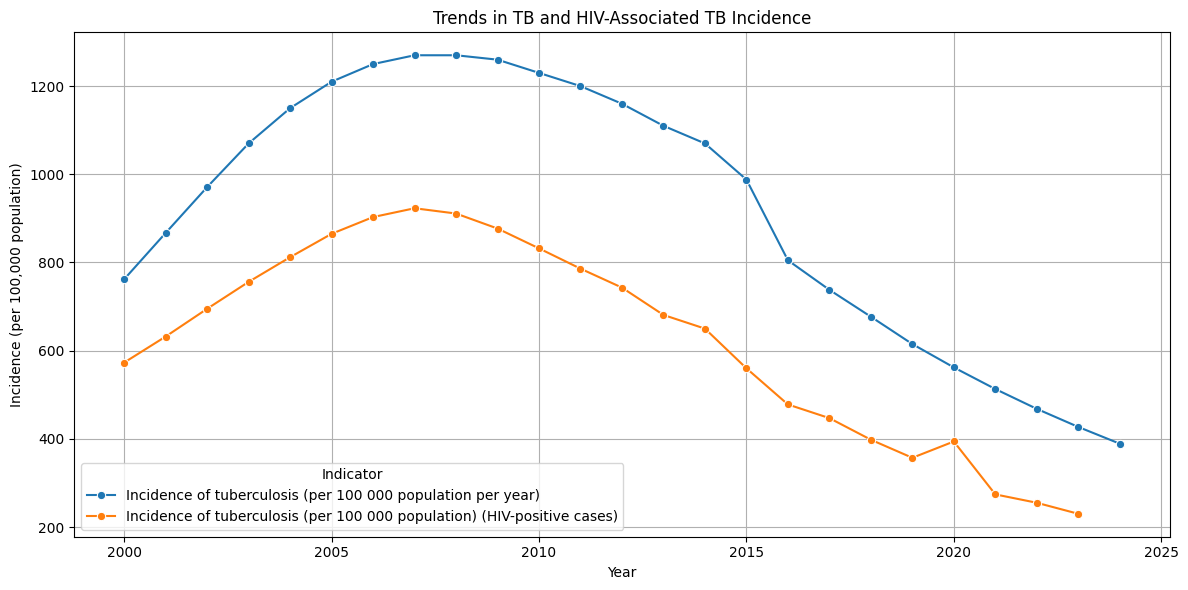

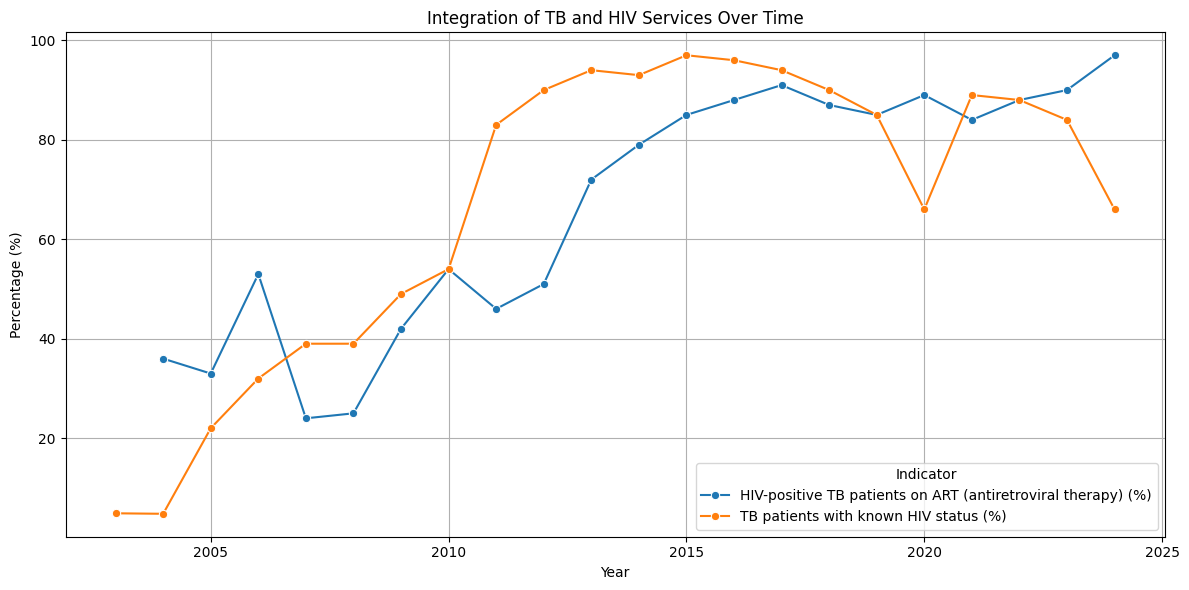

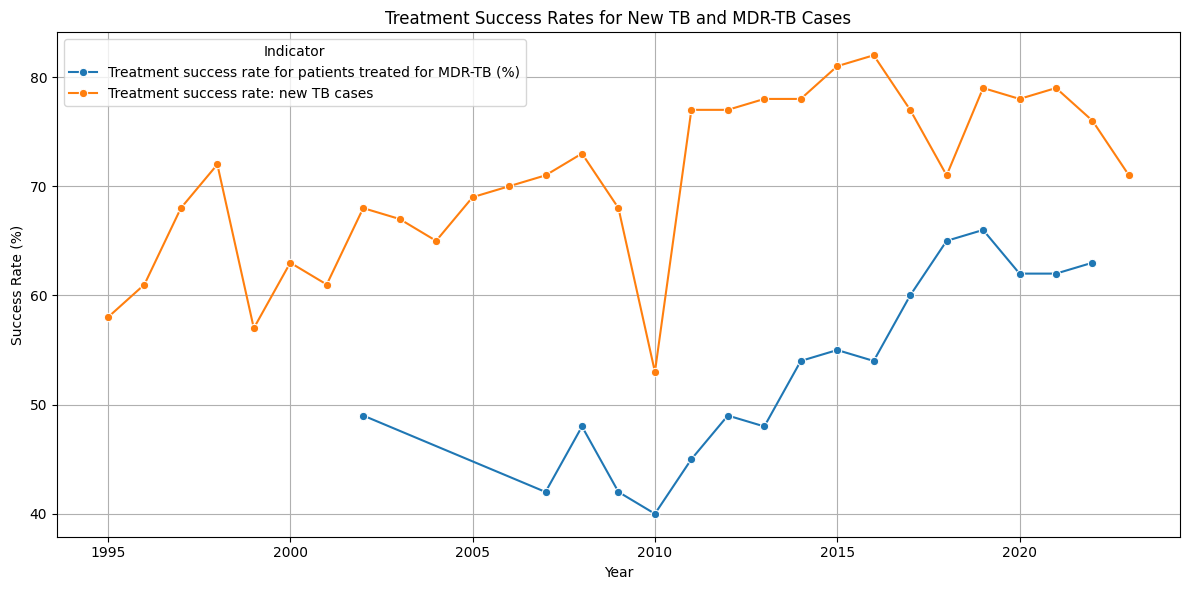

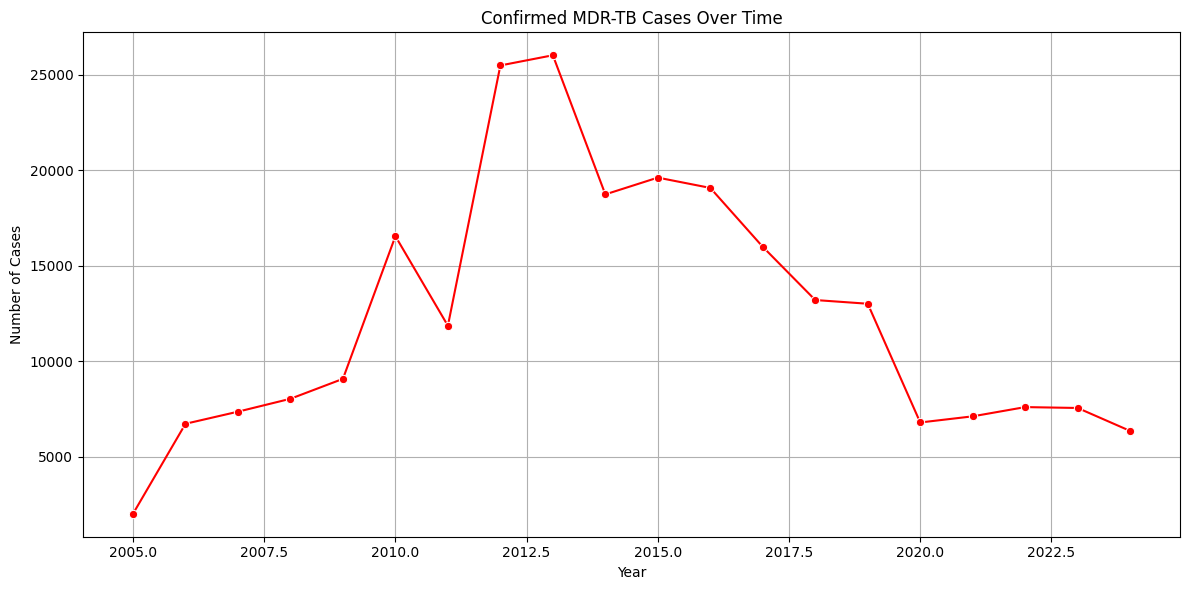

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Line plot for overall TB incidence and HIV-associated TB incidence
incidence_indicators = [
    'Incidence of tuberculosis (per 100 000 population per year)',
    'Incidence of tuberculosis (per 100 000 population) (HIV-positive cases)'
]
df_incidence = df_tb_filtered[df_tb_filtered['Indicator'].isin(incidence_indicators)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_incidence, x='Year', y='Value', hue='Indicator', marker='o')
plt.title('Trends in TB and HIV-Associated TB Incidence')
plt.xlabel('Year')
plt.ylabel('Incidence (per 100,000 population)')
plt.legend(title='Indicator')
plt.grid(True)
plt.tight_layout()
plt.savefig('tb_incidence_trends.png')
plt.show()

# 3. Line plot for integration of TB and HIV services
integration_indicators = [
    'TB patients with known HIV status (%)',
    'HIV-positive TB patients on ART (antiretroviral therapy) (%)'
]
df_integration = df_tb_filtered[df_tb_filtered['Indicator'].isin(integration_indicators)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_integration, x='Year', y='Value', hue='Indicator', marker='o')
plt.title('Integration of TB and HIV Services Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend(title='Indicator')
plt.grid(True)
plt.tight_layout()
plt.savefig('tb_hiv_integration.png')
plt.show()

# 4. Line plot for treatment success rates
treatment_success_indicators = [
    'Treatment success rate: new TB cases',
    'Treatment success rate for patients treated for MDR-TB (%)'
]
df_treatment_success = df_tb_filtered[df_tb_filtered['Indicator'].isin(treatment_success_indicators)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_treatment_success, x='Year', y='Value', hue='Indicator', marker='o')
plt.title('Treatment Success Rates for New TB and MDR-TB Cases')
plt.xlabel('Year')
plt.ylabel('Success Rate (%)')
plt.legend(title='Indicator')
plt.grid(True)
plt.tight_layout()
plt.savefig('tb_treatment_success.png')
plt.show()

# 5. Line plot for burden of MDR-TB
df_mdr_burden = df_tb_filtered[df_tb_filtered['Indicator'] == 'Confirmed cases of RR-/MDR-TB']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_mdr_burden, x='Year', y='Value', marker='o', color='red')
plt.title('Confirmed MDR-TB Cases Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.tight_layout()
plt.savefig('mdr_tb_burden.png')
plt.show()